Step 2 – Data Cleaning

In [3]:
import pandas as pd
import numpy as np

# Load the dataset
# Note: this dataset uses semicolons as separators
local_path = 'data/student-mat.csv'
try:
    df = pd.read_csv(local_path, sep=';')
except FileNotFoundError:
    import os, urllib.request, zipfile, io
    os.makedirs('data', exist_ok=True)
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip'
    print(f"File not found at {local_path}. Downloading from {url} ...")
    resp = urllib.request.urlopen(url)
    with zipfile.ZipFile(io.BytesIO(resp.read())) as z:
        for name in z.namelist():
            if name.endswith('student-mat.csv'):
                z.extract(name, 'data')
                extracted = os.path.join('data', name)
                if extracted != local_path:
                    os.replace(extracted, local_path)
                break
    df = pd.read_csv(local_path, sep=';')

# ── First look ──────────────────────────────────────
print("Shape:", df.shape)           # (rows, columns)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

File not found at data/student-mat.csv. Downloading from https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip ...
Shape: (395, 33)

First 5 rows:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4 

In [4]:
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nMissing percentage:")
print((df.isnull().mean() * 100).round(2))


Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Missing percentage:
school        0.0
sex           0.0
age           0.0
address       0.0
famsize       0.0
Pstatus       0.0
Medu          0.0
Fedu          0.0
Mjob          0.0
Fjob          0.0
reason        0.0
guardian      0.0
traveltime    0.0
studytime     0.0
failures      0.0
schoolsup     0.0
famsup        0.0
paid          0.0
activities    0.0
nursery       0.0
higher        0.0
internet      0.0
romantic      

In [5]:
print("\nDuplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)


Duplicate rows: 0
After removing duplicates: (395, 33)


In [6]:
print("\nG3 (Final Grade) stats:")
print(df['G3'].describe())

# Students with G3 = 0 might be dropouts, not failed students
# Understand before removing them
print("\nStudents with G3 = 0:", (df['G3'] == 0).sum())

# You can choose to keep or remove them based on context
# Here we keep them — they represent real cases


G3 (Final Grade) stats:
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

Students with G3 = 0: 38


In [7]:
# These binary yes/no columns should be noted for encoding later
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities',
               'nursery', 'higher', 'internet', 'romantic']

print("\nUnique values in binary columns:")
for col in binary_cols:
    print(f"{col}: {df[col].unique()}")
# Output: ['yes' 'no'] — we'll encode these later


Unique values in binary columns:
schoolsup: ['yes' 'no']
famsup: ['no' 'yes']
paid: ['no' 'yes']
activities: ['no' 'yes']
nursery: ['yes' 'no']
higher: ['yes' 'no']
internet: ['no' 'yes']
romantic: ['no' 'yes']


In [8]:
df.to_csv('data/student_cleaned.csv', index=False)
print("\nCleaned data saved!")


Cleaned data saved!


Step 3 – Exploratory Data Analysis (EDA)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/student_cleaned.csv')

# Set a clean visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

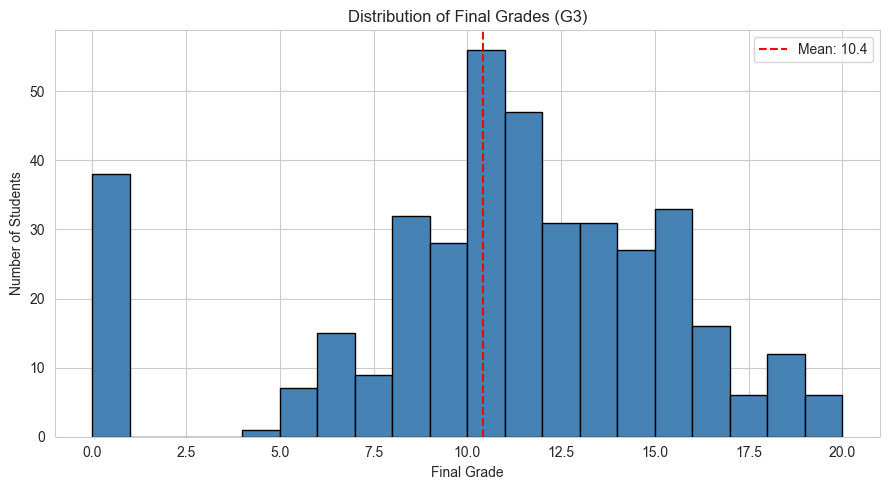

In [11]:
import os

# Always understand your target first
plt.figure(figsize=(9, 5))
df['G3'].hist(bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.axvline(df['G3'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["G3"].mean():.1f}')
plt.legend()
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/grade_distribution.png')
plt.show()

C:\Users\Rushikesh Gaikwad\AppData\Local\Temp\ipykernel_9592\1060099723.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='studytime_label', y='G3', data=df,


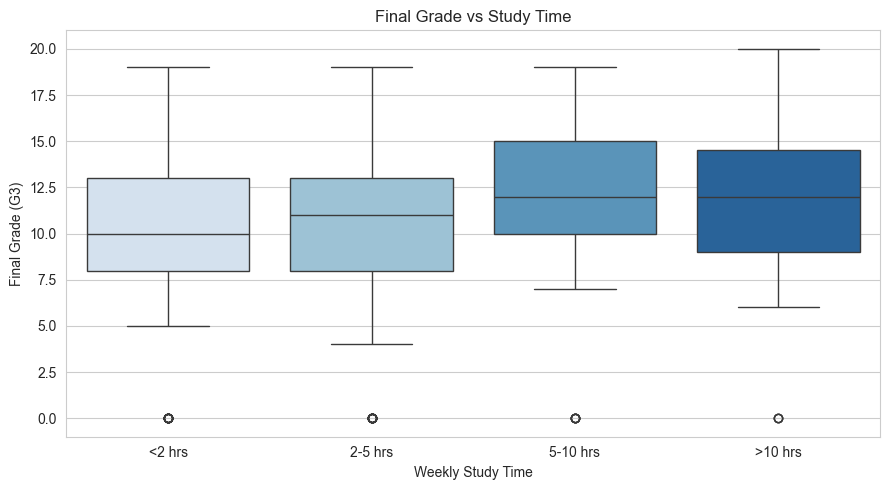

In [12]:
studytime_map = {1: '<2 hrs', 2: '2-5 hrs', 3: '5-10 hrs', 4: '>10 hrs'}
df['studytime_label'] = df['studytime'].map(studytime_map)

plt.figure(figsize=(9, 5))
sns.boxplot(x='studytime_label', y='G3', data=df,
            order=['<2 hrs', '2-5 hrs', '5-10 hrs', '>10 hrs'],
            palette='Blues')
plt.title('Final Grade vs Study Time')
plt.xlabel('Weekly Study Time')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.savefig('plots/studytime_vs_grade.png')
plt.show()

C:\Users\Rushikesh Gaikwad\AppData\Local\Temp\ipykernel_9592\1454740074.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='failures', y='G3', data=df, palette='Reds')


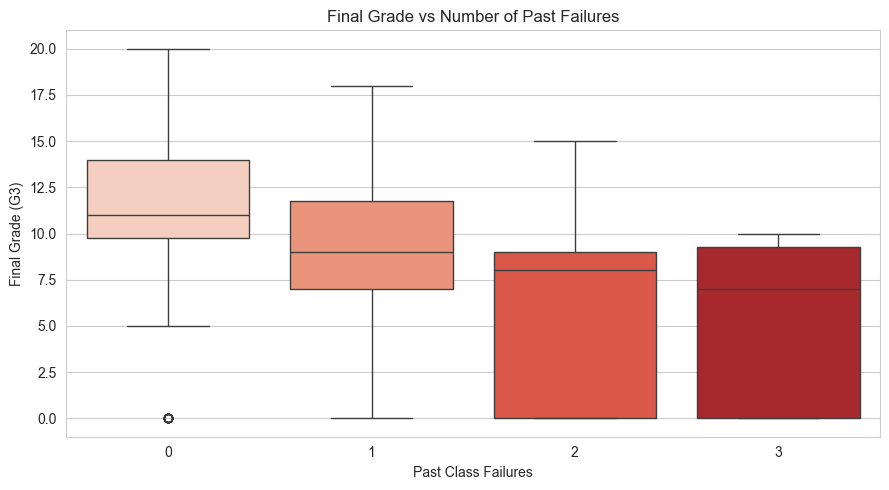

In [13]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='failures', y='G3', data=df, palette='Reds')
plt.title('Final Grade vs Number of Past Failures')
plt.xlabel('Past Class Failures')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.savefig('plots/failures_vs_grade.png')
plt.show()

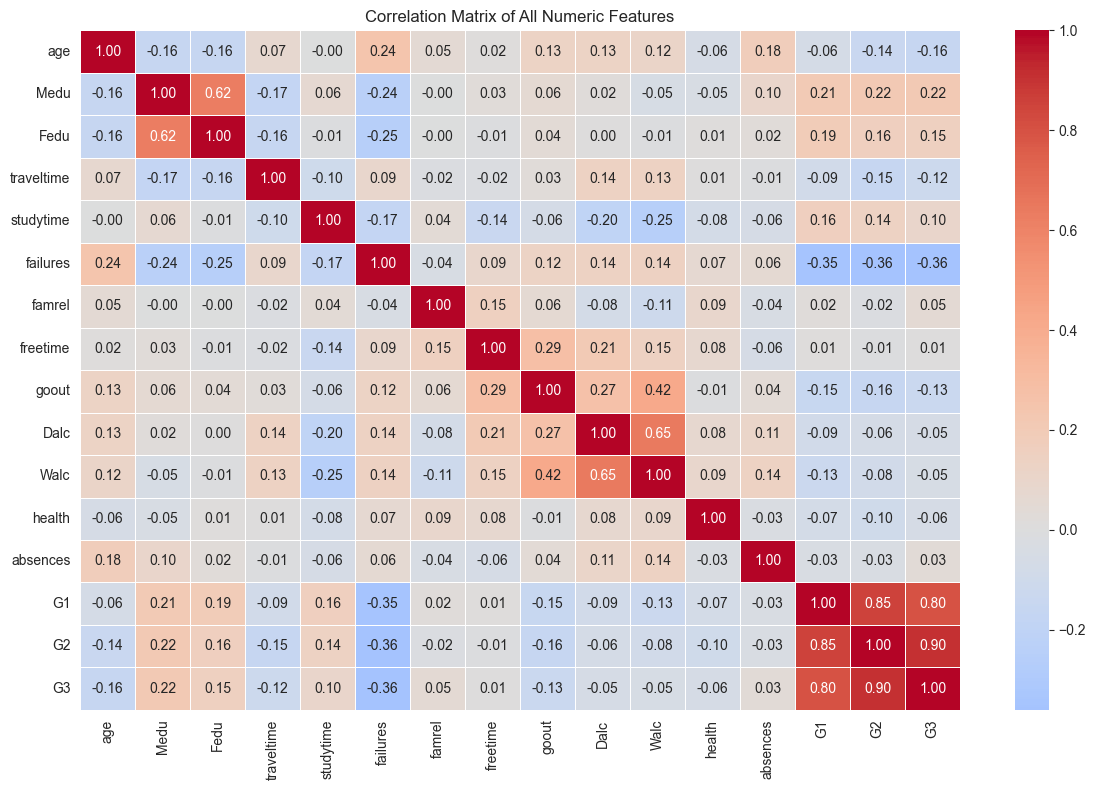

In [14]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix of All Numeric Features')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png')
plt.show()

C:\Users\Rushikesh Gaikwad\AppData\Local\Temp\ipykernel_9592\3062848833.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='internet', y='G3', data=df, palette='Set2')


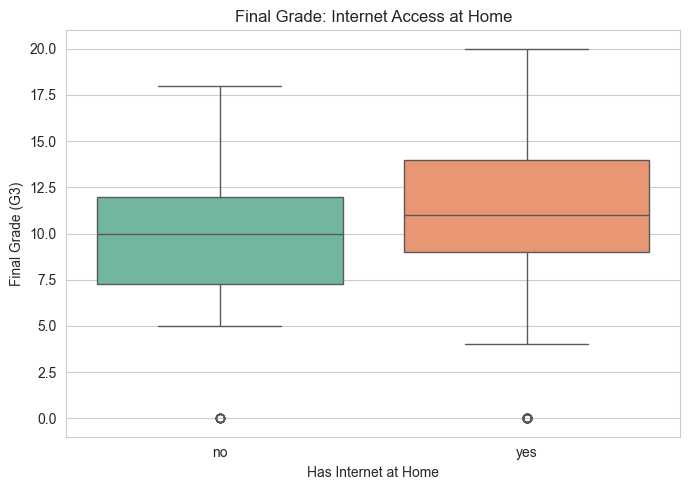

In [15]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='internet', y='G3', data=df, palette='Set2')
plt.title('Final Grade: Internet Access at Home')
plt.xlabel('Has Internet at Home')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.savefig('plots/internet_vs_grade.png')
plt.show()

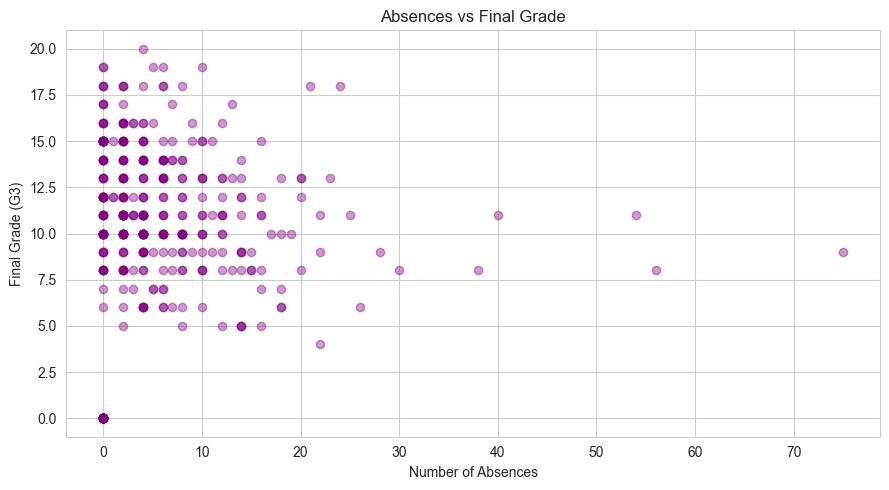

In [16]:
plt.figure(figsize=(9, 5))
plt.scatter(df['absences'], df['G3'], alpha=0.4, color='purple')
plt.title('Absences vs Final Grade')
plt.xlabel('Number of Absences')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.savefig('plots/absences_vs_grade.png')
plt.show()

Step 4 – Model Building

In [17]:
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('data/student_cleaned.csv')

# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

# Apply label encoding
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("After encoding:")
print(df.head())

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
After encoding:
   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   
3       0    0   15        1        0        1     4     2     1     3  ...   
4       0    0   16        1        0        1     3     3     2     2  ...   

   famrel  freetime  goout  Dalc  Walc  health  absences  G1  G2  G3  
0       4         3      4     1     1       3         6   5   6   6  
1       5         3      3     1     1       3         4   5   5   6  
2       4         3      2     2     3       3        10   7   8  10  
3       3         2      

In [18]:
# Correlation with G3
corr_with_target = df.corr()['G3'].sort_values(ascending=False)
print("Correlation with G3:")
print(corr_with_target)

# Drop G3 itself and pick top features
# NOTE: G1 and G2 are prior period grades — you can include or
# exclude them depending on your goal.
# Including them = high accuracy but less insight
# Excluding them = tests if lifestyle factors predict performance

# Version A: With prior grades (high accuracy model)
features_A = ['G2', 'G1', 'failures', 'studytime',
              'absences', 'higher', 'internet', 'age']

# Version B: Without prior grades (behavioural prediction model)
features_B = ['failures', 'studytime', 'absences',
              'higher', 'internet', 'age', 'Medu', 'Fedu']

# We'll go with Version A for best model performance
X = df[features_A]
y = df['G3']

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

Correlation with G3:
G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
higher        0.182465
Fedu          0.152457
reason        0.121994
address       0.105756
sex           0.103456
Mjob          0.102082
paid          0.101996
internet      0.098483
studytime     0.097820
famsize       0.081407
nursery       0.051568
famrel        0.051363
Fjob          0.042286
absences      0.034247
activities    0.016100
freetime      0.011307
famsup       -0.039157
school       -0.045017
Walc         -0.051939
Dalc         -0.054660
Pstatus      -0.058009
health       -0.061335
guardian     -0.070109
schoolsup    -0.082788
traveltime   -0.117142
romantic     -0.129970
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

Features shape: (395, 8)
Target shape: (395,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42      # For reproducibility
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 316
Testing samples:  79


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"  RMSE (lower = better): {rmse:.3f}")
    print(f"  MAE  (lower = better): {mae:.3f}")
    print(f"  R²   (higher = better): {r2:.3f}")
    
    return model, y_pred

# Train all three
lr_model,  lr_pred  = evaluate_model("Linear Regression",
                        LinearRegression(), X_train, X_test, y_train, y_test)

dt_model,  dt_pred  = evaluate_model("Decision Tree",
                        DecisionTreeRegressor(random_state=42),
                        X_train, X_test, y_train, y_test)

rf_model,  rf_pred  = evaluate_model("Random Forest",
                        RandomForestRegressor(n_estimators=100, random_state=42),
                        X_train, X_test, y_train, y_test)


Model: Linear Regression
  RMSE (lower = better): 2.109
  MAE  (lower = better): 1.339
  R²   (higher = better): 0.783

Model: Decision Tree
  RMSE (lower = better): 2.330
  MAE  (lower = better): 1.203
  R²   (higher = better): 0.735

Model: Random Forest
  RMSE (lower = better): 1.747
  MAE  (lower = better): 1.034
  R²   (higher = better): 0.851


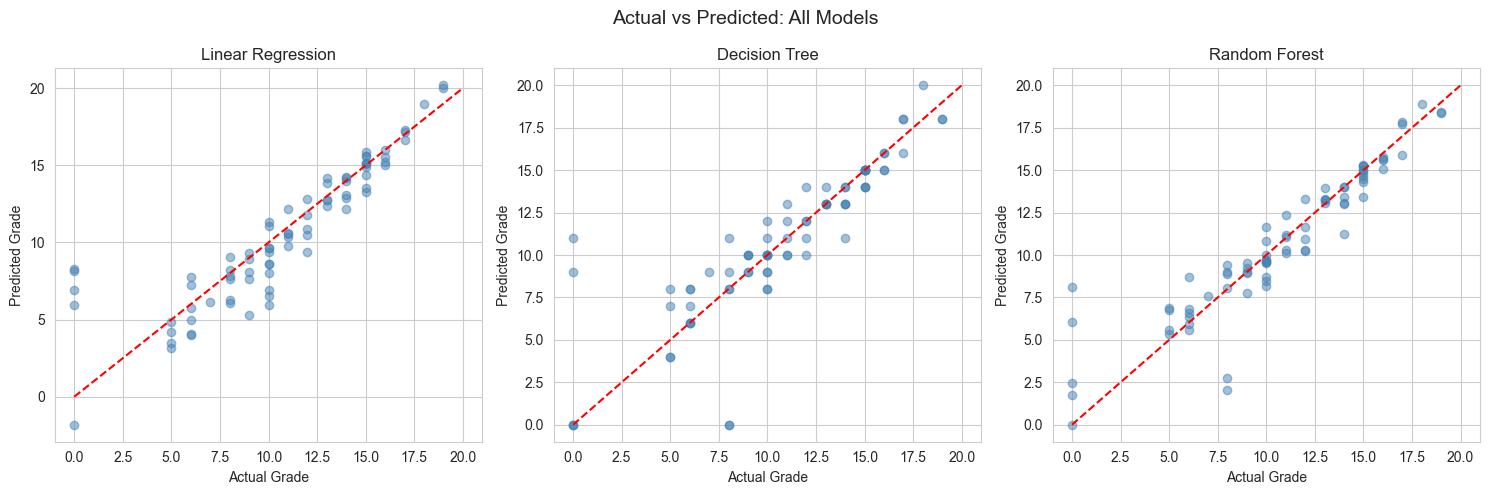

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_preds = [("Linear Regression", lr_pred),
                ("Decision Tree", dt_pred),
                ("Random Forest", rf_pred)]

for ax, (name, pred) in zip(axes, models_preds):
    ax.scatter(y_test, pred, alpha=0.5, color='steelblue')
    ax.plot([0, 20], [0, 20], 'r--')   # Perfect prediction line
    ax.set_title(name)
    ax.set_xlabel('Actual Grade')
    ax.set_ylabel('Predicted Grade')

plt.suptitle('Actual vs Predicted: All Models', fontsize=14)
plt.tight_layout()
plt.savefig('plots/model_comparison.png')
plt.show()

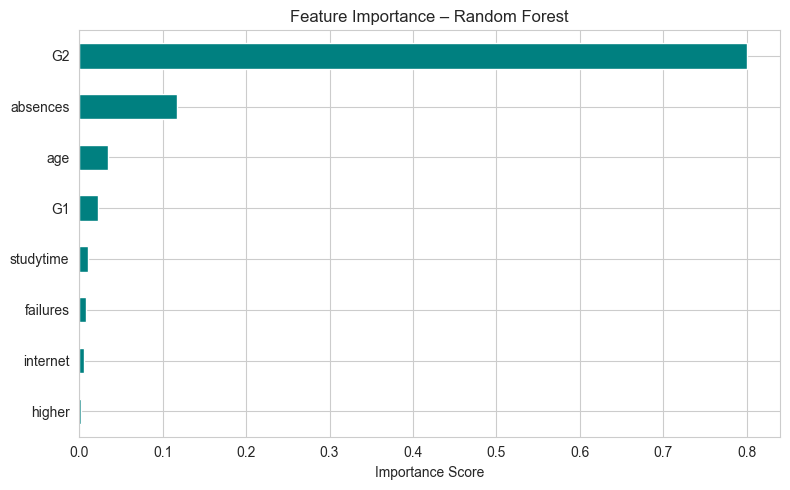

In [22]:
importances = pd.Series(rf_model.feature_importances_, index=features_A)
importances.sort_values().plot(kind='barh', color='teal', figsize=(8, 5))
plt.title('Feature Importance – Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plots/feature_importance.png')
plt.show()

In [23]:
import pickle

# Random Forest usually wins — save it
with open('model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved as model.pkl")

Model saved as model.pkl
